In [1]:
!git clone https://github.com/yiranran/APDrawingGAN.git
%cd APDrawingGAN

Cloning into 'APDrawingGAN'...
remote: Enumerating objects: 213, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 213 (delta 6), reused 5 (delta 5), pack-reused 200 (from 1)
Receiving objects: 100% (213/213), 15.48 MiB | 19.94 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/APDrawingGAN


In [2]:
import re
import matplotlib.pyplot as plt
import os
from PIL import Image
import shutil
import cv2
import numpy as np
import torchvision.transforms as T
import torch
import torch.nn as nn
from torchvision.models import resnet18
import zipfile

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load the dataset into the ./datasets folder to fine tune
zip_path = "/content/drive/MyDrive/GAN/dataset_GAN_faces_aligned.zip"
extract_to = "/content/temp_dataset"  # temp dir

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Zip extracted to:", extract_to)

# Following the structure expected for the model
# Train folder inside ./datasets
data_folder = os.path.join(extract_to, "content", "dataset_GAN_faces_aligned", "data")
dest = "./dataset"
os.makedirs(dest, exist_ok=True)

for item in os.listdir(data_folder):
    s = os.path.join(data_folder, item)
    d = os.path.join(dest, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Content from 'data' moved to ./dataset")

Zip descomprimido en: /content/temp_dataset
Contenido de 'data' movido a ./dataset


In [ ]:
# In case of needing to restart trainning, uncomment this line
#shutil.rmtree("/content/APDrawingGAN/checkpoints/sketch_to_disney/web/images", ignore_errors=True)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
!pip install torch torchvision opencv-python dominate

In [ ]:
from tqdm import tqdm

# Path to downloaded weights
zip_path = "/content/drive/MyDrive/GAN/APDrawingGAN-Models2.zip"

# Path of the weight to be able to train
extract_to = "./checkpoints"
os.makedirs(extract_to, exist_ok=True)

# Open zip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # Extract
    files = zip_ref.namelist()
    for file in tqdm(files, desc="Extracting weights"):
        zip_ref.extract(file, extract_to)

print(f"Weights processed correctly: {extract_to}")

In [ ]:
# input_nc = 1 since its sketch
# output_nc = Desired outcome is a colored image
# continue_train = Fine tuning from pre-trained models
# which_epoch = Last epoch

!export PYTHONPATH=$PYTHONPATH:/content/APDrawingGAN/train.py && \
python train.py \
--dataroot /content/APDrawingGAN/dataset \
--bg_dir  /content/APDrawingGAN/dataset/mask \
--name sketch_to_disney \
--model apdrawing_gan \
--netG unet_256 \
--dataset_mode aligned \
--which_direction AtoB \
--display_id -1 \
--batch_size 8 \
--niter 100 \
--niter_decay 100 \
--fineSize 256 \
--loadSize 286 \
--input_nc 1 \
--output_nc 3 \
--gpu_ids 0 \
--lambda_L1 100 \
--save_epoch_freq 25 \
--no_flip \
--num_threads 2

Found epochs: [25, 50, 75, 100, 125, 150, 175, 200]


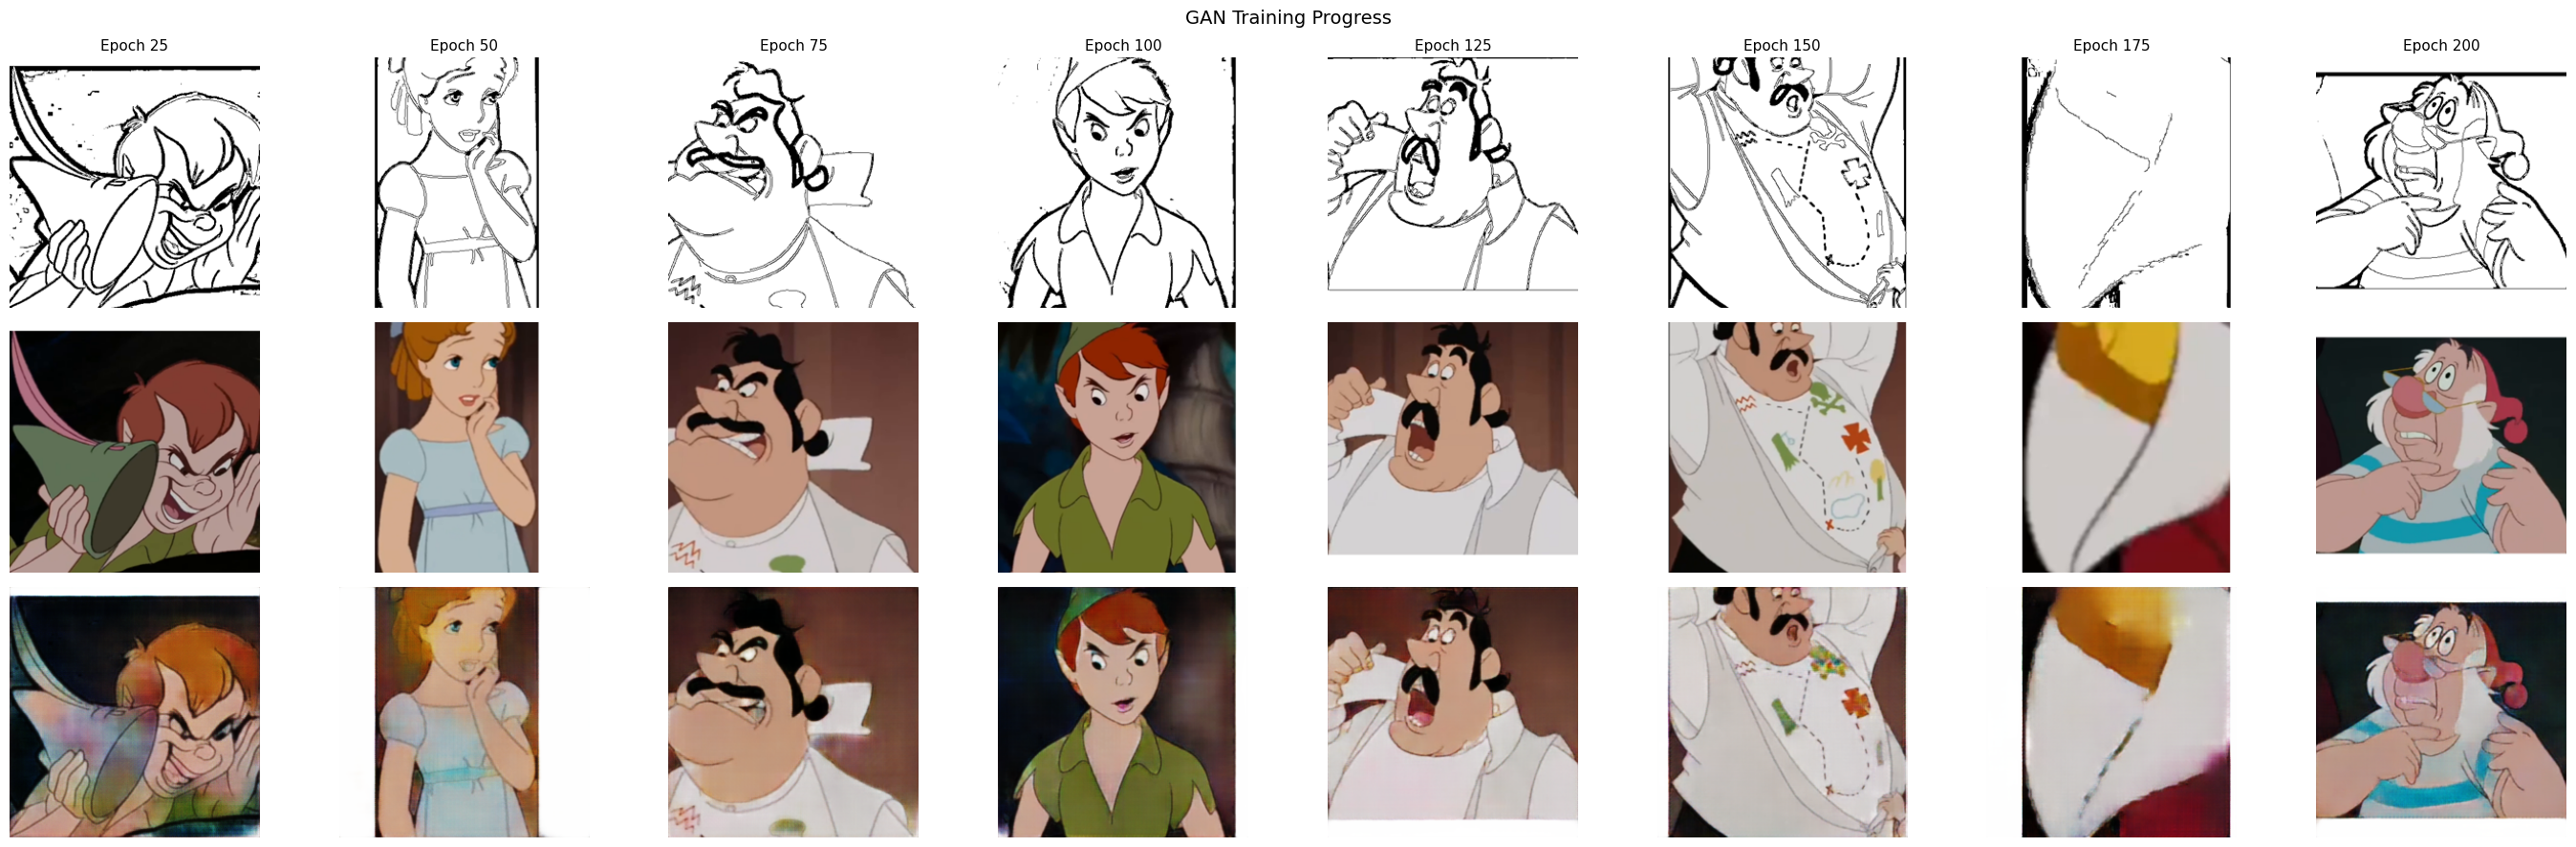

Saved: /content/gan_progress.png


In [11]:
def plot_gan_progress(web_images_dir, epochs=[25, 50, 75, 100, 125, 150, 175, 200], save_path="/content/gan_progress.png"):

    # Autodetect available epochs
    files = os.listdir(web_images_dir)
    detected = sorted({int(m.group(1)) for f in files if (m := re.match(r'epoch(\d+)_real_A\.png', f))})
    available = [ep for ep in epochs if ep in detected] or detected
    print(f"Found epochs: {available}")

    fig, axes = plt.subplots(3, len(available), figsize=(3.5 * len(available), 9))
    if len(available) == 1:
        axes = axes.reshape(3, 1)

    for col, ep in enumerate(available):
        prefix = f"epoch{ep:03d}"
        for row, key in enumerate(['real_A', 'real_B', 'fake_B']):
            ax = axes[row, col]
            path = os.path.join(web_images_dir, f"{prefix}_{key}.png")
            if os.path.exists(path):
                ax.imshow(np.array(Image.open(path).convert('RGB')))
            else:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', color='white', transform=ax.transAxes)
            ax.axis('off')
            if row == 0:
                ax.set_title(f'Epoch {ep}', fontsize=11)

    for row, label in enumerate(['Real A (sketch)', 'Real B (target)', 'Fake B (generated)']):
        axes[row, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=70, va='center')

    plt.suptitle('GAN Training Progress', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


plot_gan_progress(
    web_images_dir="/content/APDrawingGAN/checkpoints/sketch_to_disney_v2/web/images",
    epochs=[25, 50, 75, 100, 125, 150, 175, 200]
)

Parsed 561 entries, epochs 1–200


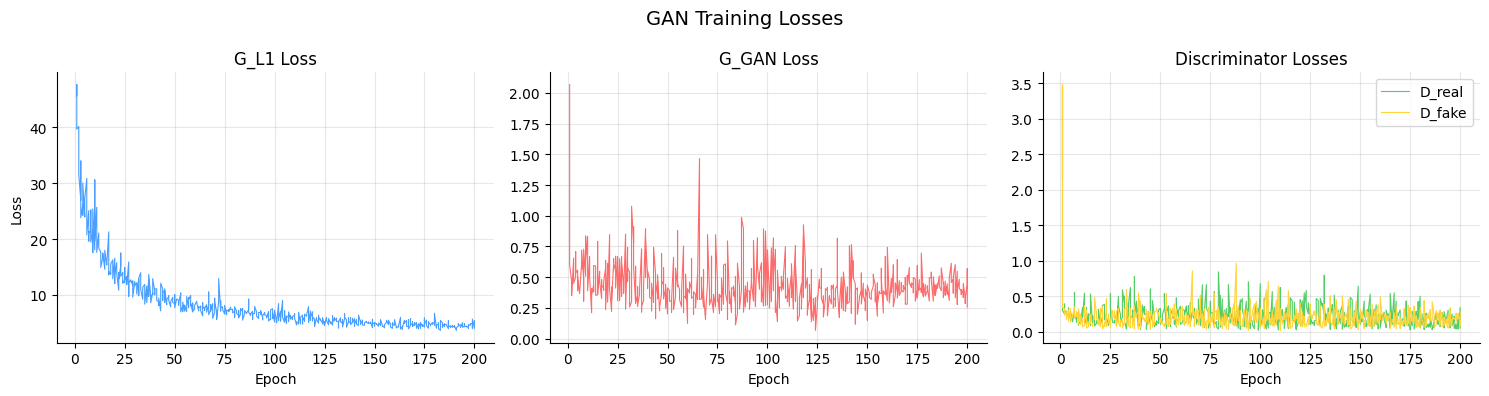

Saved: /content/gan_losses.png


In [12]:
def plot_gan_losses(log_path, save_path="/content/gan_losses.png"):

    epochs, G_GAN, G_L1, D_real, D_fake = [], [], [], [], []

    with open(log_path, 'r') as f:
        for line in f:
            m = re.search(r'epoch: (\d+).*G_GAN: ([\d.]+).*G_L1: ([\d.]+).*D_real: ([\d.]+).*D_fake: ([\d.]+)', line)
            if m:
                epochs.append(int(m.group(1)))
                G_GAN.append(float(m.group(2)))
                G_L1.append(float(m.group(3)))
                D_real.append(float(m.group(4)))
                D_fake.append(float(m.group(5)))

    print(f"Parsed {len(epochs)} entries, epochs {epochs[0]}–{epochs[-1]}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, G_L1, color='#4a9eff', linewidth=0.8)
    axes[0].set_title('G_L1 Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[1].plot(epochs, G_GAN, color='#ff6b6b', linewidth=0.8)
    axes[1].set_title('G_GAN Loss')
    axes[1].set_xlabel('Epoch')

    axes[2].plot(epochs, D_real, color='#51cf66', linewidth=0.8, label='D_real')
    axes[2].plot(epochs, D_fake, color='#ffd43b', linewidth=0.8, label='D_fake')
    axes[2].set_title('Discriminator Losses')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()

    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('GAN Training Losses', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


plot_gan_losses("/content/APDrawingGAN/checkpoints/sketch_to_disney_v2/loss_log.txt")

In [ ]:
# Let´s download the weights for the model
checkpoint = torch.load("./checkpoints/sketch_to_disney_v2/200_net_gen.pt")
netG_state_dict = checkpoint["G"]
torch.save(netG_state_dict, "generator.pt")